In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

df = pd.read_excel(r"C:\Users\pulina\Desktop\2025-Y2-S1-MLB-B6G2-01\data\yahoo_data.xlsx")

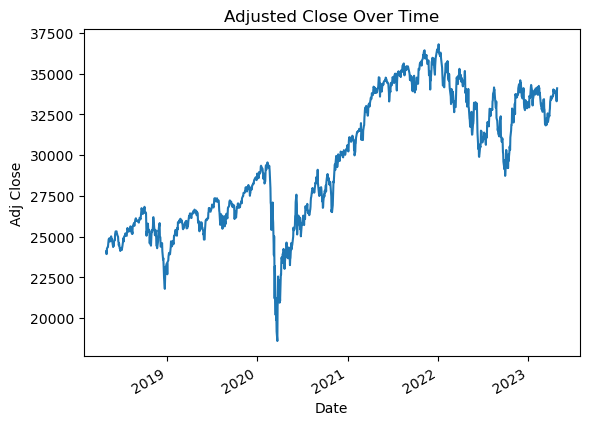

In [2]:
# === Bandara N.H.M.W.W.D.S: Date Conversion & Sorting ===
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').set_index('Date')

# Visualization
df['Adj Close**'].plot(title="Adjusted Close Over Time")
plt.xlabel("Date"); plt.ylabel("Adj Close")
plt.show()


In [3]:
# === Dewmini D M I : Handling Missing Data ===
print("Missing values before:\n", df.isna().sum())
df = df.ffill().bfill()
print("Missing values after:\n", df.isna().sum())
print("Step 2 done.")

Missing values before:
 Open           0
High           0
Low            0
Close*         0
Adj Close**    0
Volume         0
dtype: int64
Missing values after:
 Open           0
High           0
Low            0
Close*         0
Adj Close**    0
Volume         0
dtype: int64
Step 2 done.


Outliers removed: 55


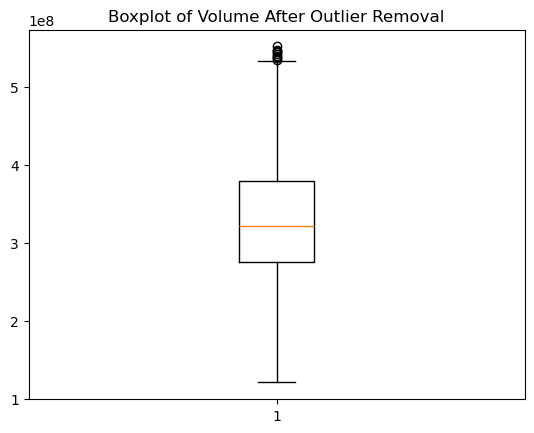

Step 3 done.


In [4]:
# === Cooray N.T.Y: Outlier Removal (IQR) ===
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

low, high = iqr_bounds(df['Volume'])
mask = (df['Volume'] >= low) & (df['Volume'] <= high)

print("Outliers removed:", (~mask).sum())
df = df[mask]

plt.boxplot(df['Volume'])
plt.title("Boxplot of Volume After Outlier Removal")
plt.show()
print("Step 3 done.")


In [5]:
# === Wicramaarachchi W C L: Normalization / Scaling ===
cols = ['Open','High','Low','Close*','Adj Close**','Volume']
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[cols])

for i, col in enumerate(cols):
    df[col + "_scaled"] = scaled[:, i]

print(df.head())
print("Step 4 done.")

                Open      High       Low    Close*  Adj Close**     Volume  \
Date                                                                         
2018-05-01  24117.29  24117.29  23808.19  24099.05     24099.05  380070000   
2018-05-02  24097.63  24185.52  23886.30  23924.98     23924.98  385350000   
2018-05-03  23836.23  23996.15  23531.31  23930.15     23930.15  389240000   
2018-05-04  23865.22  24333.35  23778.87  24262.51     24262.51  329480000   
2018-05-07  24317.66  24479.45  24263.42  24357.32     24357.32  307670000   

            Open_scaled  High_scaled  Low_scaled  Close*_scaled  \
Date                                                              
2018-05-01     0.207370     0.172171    0.193269       0.199011   
2018-05-02     0.206134     0.176571    0.198181       0.188033   
2018-05-03     0.189697     0.164358    0.175856       0.188359   
2018-05-04     0.191519     0.186106    0.191425       0.209320   
2018-05-07     0.219969     0.195529    0.221898   

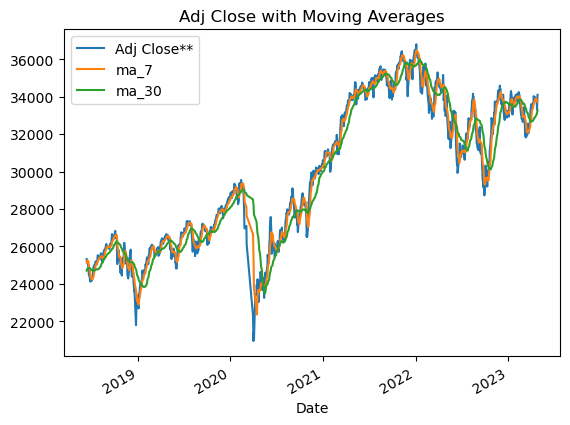

Step 5 done.


In [6]:
# === Pethvan P.P: Feature Engineering ===
df['ret_1d'] = df['Adj Close**'].pct_change()
df['ma_7'] = df['Adj Close**'].rolling(7).mean()
df['ma_30'] = df['Adj Close**'].rolling(30).mean()
df['vol_14'] = df['ret_1d'].rolling(14).std()

df = df.dropna()

df[['Adj Close**','ma_7','ma_30']].plot(title="Adj Close with Moving Averages")
plt.show()
print("Step 5 done.")

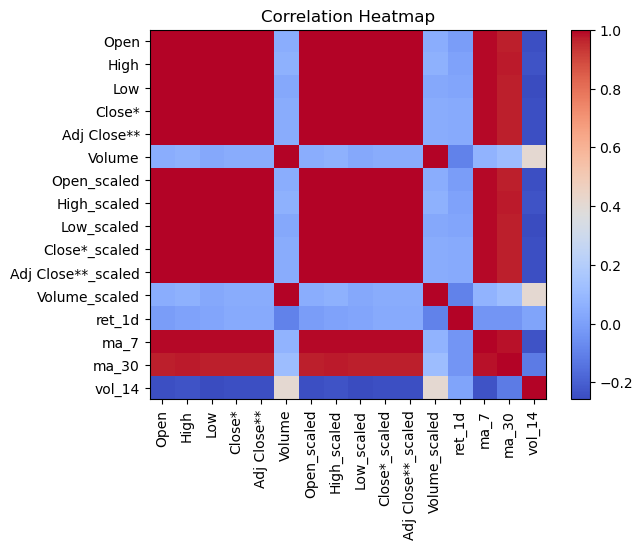

Dropped 'Close*' due to high correlation
Step 6 done.


In [7]:
# === Alagoda W.M.T.T.: Correlation & Feature Selection ===
df['ret_1d'] = df['Adj Close**'].pct_change().fillna(0)

corr = df.corr()
plt.imshow(corr.values, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

if corr.loc['Close*','Adj Close**'] > 0.98:
    df = df.drop(columns=['Close*'])
    print("Dropped 'Close*' due to high correlation")

print("Step 6 done.")

In [9]:
# === Save Final Processed Dataset ===
output_path = r"C:\Users\pulina\Desktop\2025-Y2-S1-MLB-B6G2-01\results\outputs\processed_data.xlsx"
df.to_excel(output_path, index=True)
print(f"Processed dataset saved to: {output_path}")

Processed dataset saved to: C:\Users\pulina\Desktop\2025-Y2-S1-MLB-B6G2-01\results\outputs\processed_data.xlsx
